In [1]:
!pip install requests


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\arthu\Bureau\PERSO\projetsIA\Maintenance prédictive\maintenance_predictive_venv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
from dotenv import load_dotenv
import os

load_dotenv() 


True

In [3]:
#on télécharge le dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\arthu\.cache\kagglehub\datasets\behrad3d\nasa-cmaps\versions\1


In [4]:
import pandas as pd
import os

file_path = os.path.join(path+"/CMaps", "train_FD001.txt")

columns = [
    "unit", "time",
    "setting1", "setting2", "setting3",
    "s1","s2","s3","s4","s5","s6","s7","s8","s9","s10",
    "s11","s12","s13","s14","s15","s16","s17","s18","s19","s20","s21"
]

train = pd.read_csv(file_path, sep="\s+", header=None, names=columns)

train.head()

,unit,time,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
test_path = os.path.join(path+"/CMaps", "test_FD001.txt")
rul_path = os.path.join(path+"/CMaps", "RUL_FD001.txt")

test = pd.read_csv(test_path, sep=r"\s+", header=None, names=columns)
rul = pd.read_csv(rul_path, header=None, names=["RUL"])

In [6]:
train["max_cycle"] = train.groupby("unit")["time"].transform("max")
train["RUL"] = train["max_cycle"] - train["time"]
train.drop(columns=["max_cycle"], inplace=True)

In [7]:
features = [col for col in train.columns if "s" in col] + ["setting1", "setting2", "setting3"]

X_train = train[features]
y_train = train["RUL"]



In [8]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

In [9]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_np, y_train_np)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [10]:
pred_train = model.predict(X_train_np)
rmse = np.sqrt(mean_squared_error(y_train, pred_train))

print("Train RMSE:", rmse)

Train RMSE: 32.70546344064226


In [11]:
X_test_np = test[features].to_numpy()
pred_test = model.predict(X_test_np)

In [12]:
test_last = test.groupby("unit").last().reset_index()
features = [col for col in train.columns if "s" in col] + ["setting1", "setting2", "setting3"]

X_test_final = test_last[features].to_numpy()

In [13]:
pred_test = model.predict(X_test_final)

In [14]:
rmse_test = np.sqrt(mean_squared_error(rul["RUL"], pred_test))
print("Test RMSE:", rmse_test)

Test RMSE: 33.34430097072905


In [15]:
import shap

explainer = shap.Explainer(model)

In [16]:
X_sample = X_train_np[:1000]

shap_values = explainer(X_sample)

In [17]:
print(X_sample)

[[-7.0e-04 -4.0e-04  1.0e+02 ... -7.0e-04 -4.0e-04  1.0e+02]
 [ 1.9e-03 -3.0e-04  1.0e+02 ...  1.9e-03 -3.0e-04  1.0e+02]
 [-4.3e-03  3.0e-04  1.0e+02 ... -4.3e-03  3.0e-04  1.0e+02]
 ...
 [ 1.0e-03 -0.0e+00  1.0e+02 ...  1.0e-03 -0.0e+00  1.0e+02]
 [ 2.0e-04 -3.0e-04  1.0e+02 ...  2.0e-04 -3.0e-04  1.0e+02]
 [ 1.9e-03  2.0e-04  1.0e+02 ...  1.9e-03  2.0e-04  1.0e+02]]


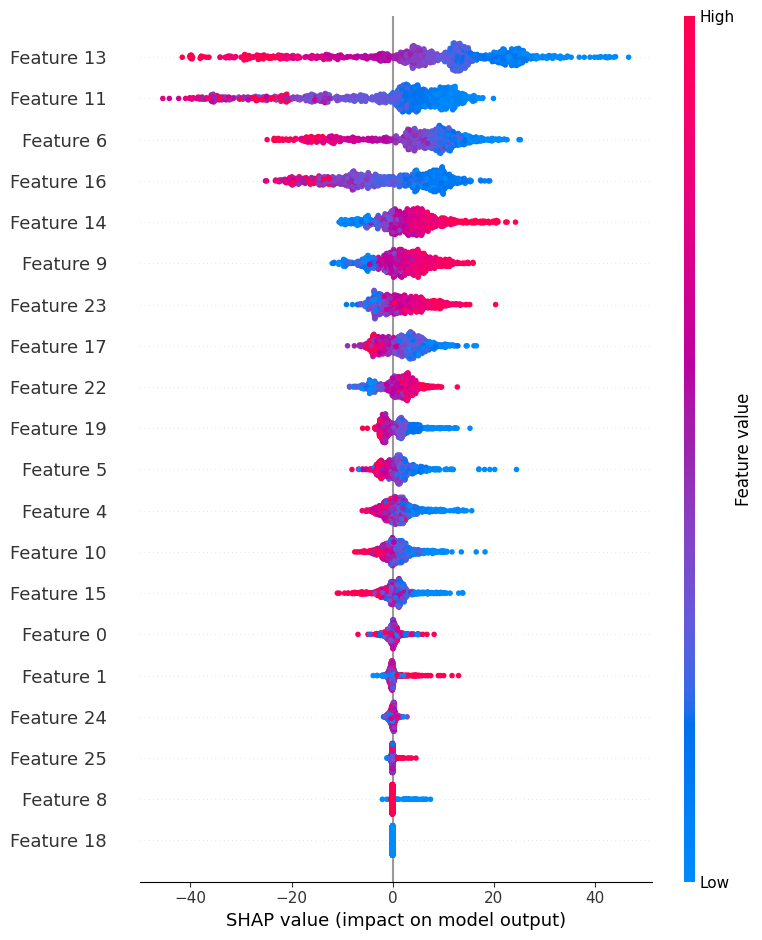

In [18]:
shap.summary_plot(shap_values, X_sample)

On teste l'IA générative pour générer des rapport avec les top features pour simplifier

In [19]:
cmapss_sensors_names = {
    "s1": "Température à l'entrée du ventilateur",
    "s2": "Température à la sortie du compresseur BP (LPC)",
    "s3": "Température à la sortie du compresseur HP (HPC)",
    "s4": "Température à la sortie de la turbine HP (HPT)",
    "s5": "Pression à l'entrée du ventilateur",
    "s6": "Pression totale dans le conduit de dérivation",
    "s7": "Pression à la sortie du compresseur BP (LPC)",
    "s8": "Vitesse physique du ventilateur",
    "s9": "Vitesse physique du cœur",
    "s10": "Pression statique à la sortie du compresseur HP (HPC)",
    "s11": "Pression à la sortie de la turbine HP (HPT)",
    "s12": "Vitesse corrigée du ventilateur",
    "s13": "Vitesse corrigée du cœur",
    "s14": "Rapport de pression de carburant",
    "s15": "Pression statique à la sortie du ventilateur",
    "s16": "Pression totale à la sortie du ventilateur",
    "s17": "Pression à la sortie de la turbine BP (LPT)",
    "s18": "Rapport de pression du moteur",
    "s19": "Pression de décharge du brûleur",
    "s20": "Débit d'air du conduit de dérivation",
    "s21": "Pression totale à la sortie de la turbine BP (LPT)"
}

In [20]:
rul_value = pred_test[0]

# exemple simplifié (tu peux remplacer avec vrai SHAP après)
top_features = {
    "s7": 12.5,
    "s12": 8.2,
    "s3": -4.1
}

In [21]:
def build_prompt(rul, features):
    return f"""
You are an industrial maintenance expert.

Machine status:
- Remaining Useful Life: {rul:.1f} cycles

Sensor analysis:
{features}

Generate:
1. A short diagnostic
2. Probable causes
3. Recommended actions
"""

In [22]:
import shap
import xgboost as xgb
import google.genai as genai
import os

# 1. Dictionnaire complet des capteurs CMAPSS
cmapss_mapping = {
    "s1": "Température entrée ventilateur", "s2": "Température sortie LPC",
    "s3": "Température sortie HPC", "s4": "Température sortie LPT",
    "s5": "Pression entrée ventilateur", "s6": "Pression conduit dérivation",
    "s7": "Pression totale sortie LPC", "s8": "Vitesse physique ventilateur",
    "s9": "Vitesse physique cœur", "s10": "Pression statique sortie HPC",
    "s11": "Pression sortie turbine HP", "s12": "Vitesse corrigée ventilateur",
    "s13": "Vitesse corrigée cœur", "s14": "Rapport pression carburant",
    "s15": "Pression statique sortie ventilateur", "s16": "Pression totale sortie ventilateur",
    "s17": "Pression sortie turbine BP", "s18": "Rapport pression moteur",
    "s19": "Pression décharge brûleur", "s20": "Débit air conduit dérivation",
    "s21": "Pression totale sortie turbine BP"
}

def generate_full_report(model_xgb, X_instance, feature_names):
    # Calcul SHAP
    explainer = shap.TreeExplainer(model_xgb)
    shap_values = explainer.shap_values(X_instance)
    predicted_rul = model_xgb.predict(X_instance)[0]
    
    # Préparation de TOUTES les données capteurs pour le prompt
    sensor_analysis = ""
    for i, name in enumerate(feature_names):
        clean_name = cmapss_mapping.get(name, name)
        impact = shap_values[0, i]
        sensor_analysis += f"- {clean_name} ({name}) : {impact:.2f} cycles\n"

    # Prompt exhaustif
    prompt = f"""
    Tu es un ingénieur expert en diagnostic moteur. Voici l'analyse complète des capteurs d'un turboréacteur.
    
    RÉSULTATS DU MODÈLE :
    - RUL (Durée de vie restante) prédite : {predicted_rul:.1f} cycles.
    
    VALEURS D'IMPACT SHAP POUR TOUS LES CAPTEURS :
    {sensor_analysis}
    
    CONSIGNE :
    1. Analyse l'ensemble de ces données pour identifier des tendances (ex: plusieurs capteurs de température en hausse).
    2. Rédige un rapport technique expliquant l'état de santé global du moteur.
    3. Conclue sur l'urgence de la maintenance.
    """


    client = genai.Client(api_key=os.getenv("API_KEY"))
    
    print(prompt)
    
    response = client.models.generate_content(
        model="gemini-2.0-flash", 
        contents=prompt
    )
    
    return response.text

# Utilisation : 
print(generate_full_report(model, X_sample, cmapss_sensors_names))


    Tu es un ingénieur expert en diagnostic moteur. Voici l'analyse complète des capteurs d'un turboréacteur.

    RÉSULTATS DU MODÈLE :
    - RUL (Durée de vie restante) prédite : 183.3 cycles.

    VALEURS D'IMPACT SHAP POUR TOUS LES CAPTEURS :
    - Température entrée ventilateur (s1) : 0.67 cycles
- Température sortie LPC (s2) : -1.04 cycles
- Température sortie HPC (s3) : 0.00 cycles
- Température sortie LPT (s4) : 0.00 cycles
- Pression entrée ventilateur (s5) : 5.82 cycles
- Pression conduit dérivation (s6) : -0.04 cycles
- Pression totale sortie LPC (s7) : 9.59 cycles
- Vitesse physique ventilateur (s8) : 0.00 cycles
- Vitesse physique cœur (s9) : -0.11 cycles
- Pression statique sortie HPC (s10) : 10.84 cycles
- Pression sortie turbine HP (s11) : 0.03 cycles
- Vitesse corrigée ventilateur (s12) : 16.42 cycles
- Vitesse corrigée cœur (s13) : 0.00 cycles
- Rapport pression carburant (s14) : 9.29 cycles
- Pression statique sortie ventilateur (s15) : 0.08 cycles
- Pression totale

ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 13.924133871s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_input_token_count', 'quotaId': 'GenerateContentInputTokensPerModelPerMinute-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.0-flash'}}, {'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.0-flash'}}, {'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-2.0-flash'}}]}, {'@type': 'type.googleapis.com/google.rpc.RetryInfo', 'retryDelay': '13s'}]}}

In [23]:
test_last = test.groupby("unit").last().reset_index()

In [24]:
features = [col for col in train.columns if "s" in col] + ["setting1", "setting2", "setting3"]

X_test_final = test_last[features].values

In [25]:
pred_test = model.predict(X_test_final)


In [26]:
rmse_test = np.sqrt(mean_squared_error(rul["RUL"], pred_test))
print("Test RMSE:", rmse_test)

Test RMSE: 33.34430097072905


# Detection d'anomalies

In [27]:
from sklearn.ensemble import IsolationForest

# on prend les mêmes features que ton modèle
X_anomaly = X_train_np

model_anomaly = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # 5% anomalies
    random_state=42
)

model_anomaly.fit(X_anomaly)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [28]:

anomaly_labels = model_anomaly.predict(X_test_final)
anomaly_scores = model_anomaly.decision_function(X_test_final)

test_last = test_last.copy()
test_last["anomaly"] = anomaly_labels
test_last["anomaly_score"] = anomaly_scores

Enregistrement model pour mise en production

In [29]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(model_anomaly, open("anomaly.pkl", "wb"))

In [30]:
import numpy as np

np.save("reference.npy", X_train_np)

In [34]:

import requests

url = "http://127.0.0.1:8000/predict"

payload = {
    "data":  X_test_np[91].tolist()
}

response = requests.post(url, json=payload)

print(response.text)

{"RUL":134.90476989746094,"anomaly":1,"drift_detected":true,"drift_score":1.0602030531186135,"input_warning":true}
